# 02 — 第一代：Heuristic Filtering

**方法论定位（第一代）**：人工设计规则，按 FineWeb 实际过滤顺序执行。

过滤顺序：URL → 语言 → Gopher质量 → C4质量 → FineWeb质量 → 重复 → PII脱敏 → 毒性

**本代的核心价值和局限**：
- 可解释、极快、不需要训练
- 能过滤"明显的垃圾"（乱码、广告、模板）
- 无法区分"平庸内容"和"高质量内容"（都能通过规则）
- 规则之间无协同，阈值靠经验

> 本 notebook 读取 pipeline 预计算结果（`data/gen1_output/`），不再逐步运行过滤器。
> Pipeline 脚本：`scripts/run_gen1.py`

## A. URL 过滤

**原理**：在文本提取之前，基于 URL 字符串本身过滤明显的垃圾域名。

成本极低（只检查 URL），可以在 WARC 读取阶段就剔除，节省后续 Trafilatura 提取的计算量。

## B. 语言过滤

**原理**：使用 fastText langid 模型（支持 176 种语言）识别文档语言。

Common Crawl 中非英文文档约占 50-60%（对于英文 pipeline）。语言过滤是保证训练数据纯净度最基础的步骤。

**技术选型**：fastText langid > langdetect > cld3
- fastText langid 速度极快（微秒级/文档）
- 在短文本上精度优于其他方案
- FineWeb 和 DCLM 都用 fastText langid

## C. Gopher 质量过滤

**规则来源**：DeepMind Gopher 论文（2021）

6条核心规则，检测"明显的低质量"：
1. 文档长度（50-100000词）
2. 平均句子长度（3-1000词）
3. 字母字符占比（>70%）
4. 停用词数量（至少2个英文停用词）
5. 省略号行比例（<30%）
6. 非字母开头词比例（<20%）

## D. 内容安全过滤（毒性过滤）

> **内容安全分类是多级体系，不是"有毒/无毒"二分类**
>
> 工业级实践按**类型**（色情/暴力/仇恨/自残等）和**严重程度**（轻微/中度/严重）分级。不同类型策略不同：
> - **严重暴力、仇恨言论**：完全过滤
> - **模糊边界内容（医学/历史/新闻）**：标记但保留
> - **轻微冒犯性语言**：可改写脱敏
>
> **与 TikTok 内容安全审核的对应关系**：
> 预训练数据过滤 = 机器初筛（高阈值，宁可多杀不能漏）。
> 产品层面的内容审核 = 多级人机协同（机器粗筛 → 人工复核 → 申诉机制）。
> 两者的目标不同，阈值设置逻辑也不同。
>
> **Precision-Recall 困境**：
> - 阈值 0.5：过滤 X%，但医学文本/新闻报道可能被误杀
> - 阈值 0.85：漏杀率高，但误杀率低
> - 阈值 0.95：极保守，几乎只过滤最明显的有害内容
>
> 没有完美阈值，只有根据场景做的 trade-off。

In [1]:
# === Cell A: 环境初始化 + 双模式数据加载 ===
# 同时加载 smoke_test 和 full_run 两档的 Gen1 pipeline 结果
# 数据来源：scripts/run_gen1.py 的输出
import sys
sys.path.insert(0, '..')
import json
import random
import numpy as np
from pathlib import Path
from src.utils.config_loader import load_run_config, get_output_path, print_config_summary

# --- 双模式数据加载 ---
MODES = ['smoke_test', 'full_run']
MODE_LABELS = {'smoke_test': 'Smoke Test (12K)', 'full_run': 'Full Run (100K)'}
dual_data = {}

for mode in MODES:
    mode_cfg = load_run_config(run_mode_override=mode)
    gen1_dir = get_output_path(1, mode_cfg)

    stats_path = gen1_dir / 'gen1_pipeline_stats.json'
    with open(stats_path) as f:
        pipeline_data = json.load(f)

    # 加载 stage_metrics 获取 token 统计
    stage_metrics_path = gen1_dir / 'gen1_stage_metrics.json'
    stage_metrics = []
    if stage_metrics_path.exists():
        with open(stage_metrics_path) as f:
            stage_metrics = json.load(f)

    dual_data[mode] = {
        'cfg': mode_cfg,
        'gen1_dir': gen1_dir,
        'pipeline_stats': pipeline_data['pipeline_stats'],
        'input_count': pipeline_data['input_count'],
        'output_count': pipeline_data['output_count'],
        'retention_rate': pipeline_data['retention_rate'],
        'stage_metrics': stage_metrics,
    }
    print(f"[{mode}] 已加载: {stats_path}")
    print(f"  输入: {pipeline_data['input_count']:,} 条 | 输出: {pipeline_data['output_count']:,} 条 | 保留率: {pipeline_data['retention_rate']:.1%}")

# --- 保留 smoke_test 的变量供 Cell C（样本文本对比）使用 ---
current_mode = 'smoke_test'
run_cfg = dual_data[current_mode]['cfg']
pipeline_stats = dual_data[current_mode]['pipeline_stats']
input_count = dual_data[current_mode]['input_count']
output_count = dual_data[current_mode]['output_count']
retention_rate = dual_data[current_mode]['retention_rate']
gen1_dir = dual_data[current_mode]['gen1_dir']

print(f"\n当前详细分析模式: {current_mode}")
print_config_summary(run_cfg)

# --- 加载原始文档样本（仅当前 mode） ---
raw_dir = get_output_path(0, run_cfg)
raw_docs = []
jsonl_files = list(raw_dir.glob('*.jsonl'))
if jsonl_files:
    with open(jsonl_files[0]) as f:
        for i, line in enumerate(f):
            if i >= run_cfg['doc_limit']:
                break
            try:
                raw_docs.append(json.loads(line))
            except Exception:
                pass
print(f"原始文档加载: {len(raw_docs):,} 条")

# --- 加载 gen1 输出文档样本（仅当前 mode） ---
output_path = gen1_dir / 'gen1_output.jsonl'
gen1_docs = []
with open(output_path) as f:
    for line in f:
        try:
            gen1_docs.append(json.loads(line))
        except Exception:
            pass
print(f"Gen1 输出文档加载: {len(gen1_docs):,} 条")

[smoke_test] 已加载: /Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/fineweb-pipeline/notebooks/../data/gen1_output/smoke_test/gen1_pipeline_stats.json
  输入: 12,000 条 | 输出: 409 条 | 保留率: 3.4%
[full_run] 已加载: /Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/fineweb-pipeline/notebooks/../data/gen1_output/full_run/gen1_pipeline_stats.json
  输入: 100,000 条 | 输出: 3,242 条 | 保留率: 3.2%

当前详细分析模式: smoke_test
  当前运行模式: SMOKE_TEST
  20-30分钟跑完，验证代码 + 产出有统计意义的对比数据
──────────────────────────────────────────────────
  doc_limit       : 12,000
  eval_sample_size: 500
  audit_sample_size: 50
  rewrite_count   : 100
  random_seed     : 42
  output_subdir   : .../<run_mode>/ = .../smoke_test/


原始文档加载: 12,000 条
Gen1 输出文档加载: 409 条


In [2]:
# === Cell B: 双模式逐阶段统计对比表 ===
# 同时展示 smoke_test 和 full_run 两档的逐阶段过滤统计

# 阶段名称中英文映射
step_names = {
    'url_dedup': 'URL 去重',
    'url_filter': 'URL 过滤',
    'language_filter': '语言过滤',
    'quality_filter': '质量过滤 (Gopher+C4+FineWeb)',
    'repetition_filter': '重复过滤',
    'pii_filter': 'PII 脱敏',
    'toxicity_filter': '毒性过滤',
}

# 构建每个 mode 的 step -> stats 映射
mode_step_map = {}
for mode in MODES:
    mode_step_map[mode] = {s['step']: s for s in dual_data[mode]['pipeline_stats']}

# 获取所有阶段（按 smoke_test 的顺序）
all_steps = [s['step'] for s in dual_data['smoke_test']['pipeline_stats']]

header_w = 32  # 阶段名列宽
col_w = 28     # 每个 mode 列宽

print("=" * (header_w + col_w * 2 + 4))
print(f"  第一代 Heuristic Filtering — 双模式逐阶段对比")
print("=" * (header_w + col_w * 2 + 4))
print(f"{'阶段':<{header_w}} {'Smoke Test (12K)':^{col_w}} {'Full Run (100K)':^{col_w}}")
print(f"{'':<{header_w}} {'输入→输出 (过滤率)':^{col_w}} {'输入→输出 (过滤率)':^{col_w}}")
print("-" * (header_w + col_w * 2 + 4))

for step in all_steps:
    name = step_names.get(step, step)
    parts = []
    for mode in MODES:
        s = mode_step_map[mode].get(step)
        if s:
            parts.append(f"{s['before']:>6,}→{s['after']:<6,} ({s['filter_rate']:>5.1%})")
        else:
            parts.append(f"{'N/A':^{col_w}}")
    print(f"{name:<{header_w}} {parts[0]:^{col_w}} {parts[1]:^{col_w}}")

print("-" * (header_w + col_w * 2 + 4))

# 总计行
parts = []
for mode in MODES:
    d = dual_data[mode]
    total_filtered = d['input_count'] - d['output_count']
    total_rate = 1 - d['retention_rate']
    parts.append(f"{d['input_count']:>6,}→{d['output_count']:<6,} ({total_rate:>5.1%})")
print(f"{'总计':<{header_w}} {parts[0]:^{col_w}} {parts[1]:^{col_w}}")
print("=" * (header_w + col_w * 2 + 4))

# 保留率对比
print(f"\n保留率对比:")
for mode in MODES:
    d = dual_data[mode]
    label = MODE_LABELS[mode]
    print(f"  {label}: {d['retention_rate']:.1%} ({d['output_count']:,} / {d['input_count']:,})")

# 一致性分析
smoke_rate = dual_data['smoke_test']['retention_rate']
full_rate = dual_data['full_run']['retention_rate']
diff_pct = abs(smoke_rate - full_rate) / full_rate * 100
print(f"\n两档保留率差异: {diff_pct:.1f}%（{'一致性良好' if diff_pct < 20 else '存在显著差异'}）")

  第一代 Heuristic Filtering — 双模式逐阶段对比
阶段                                     Smoke Test (12K)             Full Run (100K)       
                                         输入→输出 (过滤率)                  输入→输出 (过滤率)         
--------------------------------------------------------------------------------------------
URL 去重                              12,000→11,997 ( 0.0%)        100,000→99,896 ( 0.1%)   
URL 过滤                              11,997→11,851 ( 1.2%)        99,896→98,452 ( 1.4%)    
语言过滤                                11,851→2,912  (75.4%)        98,452→24,026 (75.6%)    
质量过滤 (Gopher+C4+FineWeb)             2,912→832    (71.4%)        24,026→6,539  (72.8%)    
重复过滤                                   832→409    (50.8%)         6,539→3,242  (50.4%)    
PII 脱敏                                 409→409    ( 0.0%)         3,242→3,242  ( 0.0%)    
--------------------------------------------------------------------------------------------
总计                                  12,000→409   

In [3]:
# === Cell C: 样本文本对比 ===
# 展示原始输入 vs gen1 输出的文本样例
# 被过滤的文档 = 在原始数据中但不在输出中的文档（通过 URL 匹配）

random.seed(42)

# 构建 gen1 输出 URL 集合用于快速查找
gen1_urls = set(d.get('url', '') for d in gen1_docs)

# 找出被过滤掉的文档（在原始数据中但不在输出中）
filtered_docs = [d for d in raw_docs if d.get('url', '') not in gen1_urls]

print("=" * 70)
print("  被过滤掉的文档样例（3 条）")
print("=" * 70)
sample_filtered = random.sample(filtered_docs, min(3, len(filtered_docs)))
for i, d in enumerate(sample_filtered, 1):
    print(f"\n[过滤 {i}] URL: {d.get('url', 'N/A')[:80]}")
    text_preview = d.get('text', '')[:250].replace('\n', ' ')
    print(f"  文本前 250 字: {text_preview!r}")

print("\n" + "=" * 70)
print("  通过过滤的文档样例（3 条）")
print("=" * 70)
sample_passed = random.sample(gen1_docs, min(3, len(gen1_docs)))
for i, d in enumerate(sample_passed, 1):
    print(f"\n[通过 {i}] URL: {d.get('url', 'N/A')[:80]}")
    text_preview = d.get('text', '')[:250].replace('\n', ' ')
    print(f"  文本前 250 字: {text_preview!r}")

  被过滤掉的文档样例（3 条）

[过滤 1] URL: http://kalugates.ru/rybalka/korrektivy-zakona-o-gee-proshli-pervoe-chtenie.html
  文本前 250 字: 'Коррективы закона о ГЭЭ прошли первое чтение - Kaluga Hunt-Fish. Перейти к содержанию Kaluga Hunt-Fish. Охота и Рыбалка: информационный портал. Охота Рыбалка Оружие Фото Кухня Туризм Экология Карта сайта Найти: Главное Меню Рыбалка Коррективы закона '

[过滤 2] URL: http://andreuccitorrejonabogados.cl/
  文本前 250 字: 'One moment, please... Please wait while your request is being verified...'

[过滤 3] URL: http://drvdavphillaur.com/Event-Calendar
  文本前 250 字: '\u200bDRV DAV Centenary Public School,\u200b Phillaur (Distt. Jalandhar) ABOUT DAVCMC ARYA SAMAJ PRESIDENT’s MESSAGE DAVCMC VIDEOS ALUMNI DAVCMC INTELLECTUAL HUB \u200bDRV DAV Centenary Public School,PHILLAUR Distt Jalandhar (Punjab) Affiliated to CBSE, New Delhi H'

  通过过滤的文档样例（3 条）

[通过 1] URL: http://foodgovernance.com/agroecology-at-the-committee-on-world-food-security/
  文本前 250 字: 'Food Governance | Agroecol

/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_8472/3828655642.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(stages, rotation=30, ha='right', fontsize=9)
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_8472/3828655642.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(stages[1:], rotation=30, ha='right', fontsize=9)
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_8472/3828655642.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(stages, rotation=30, ha='right', fontsize=9)
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_8472/3828655642.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e

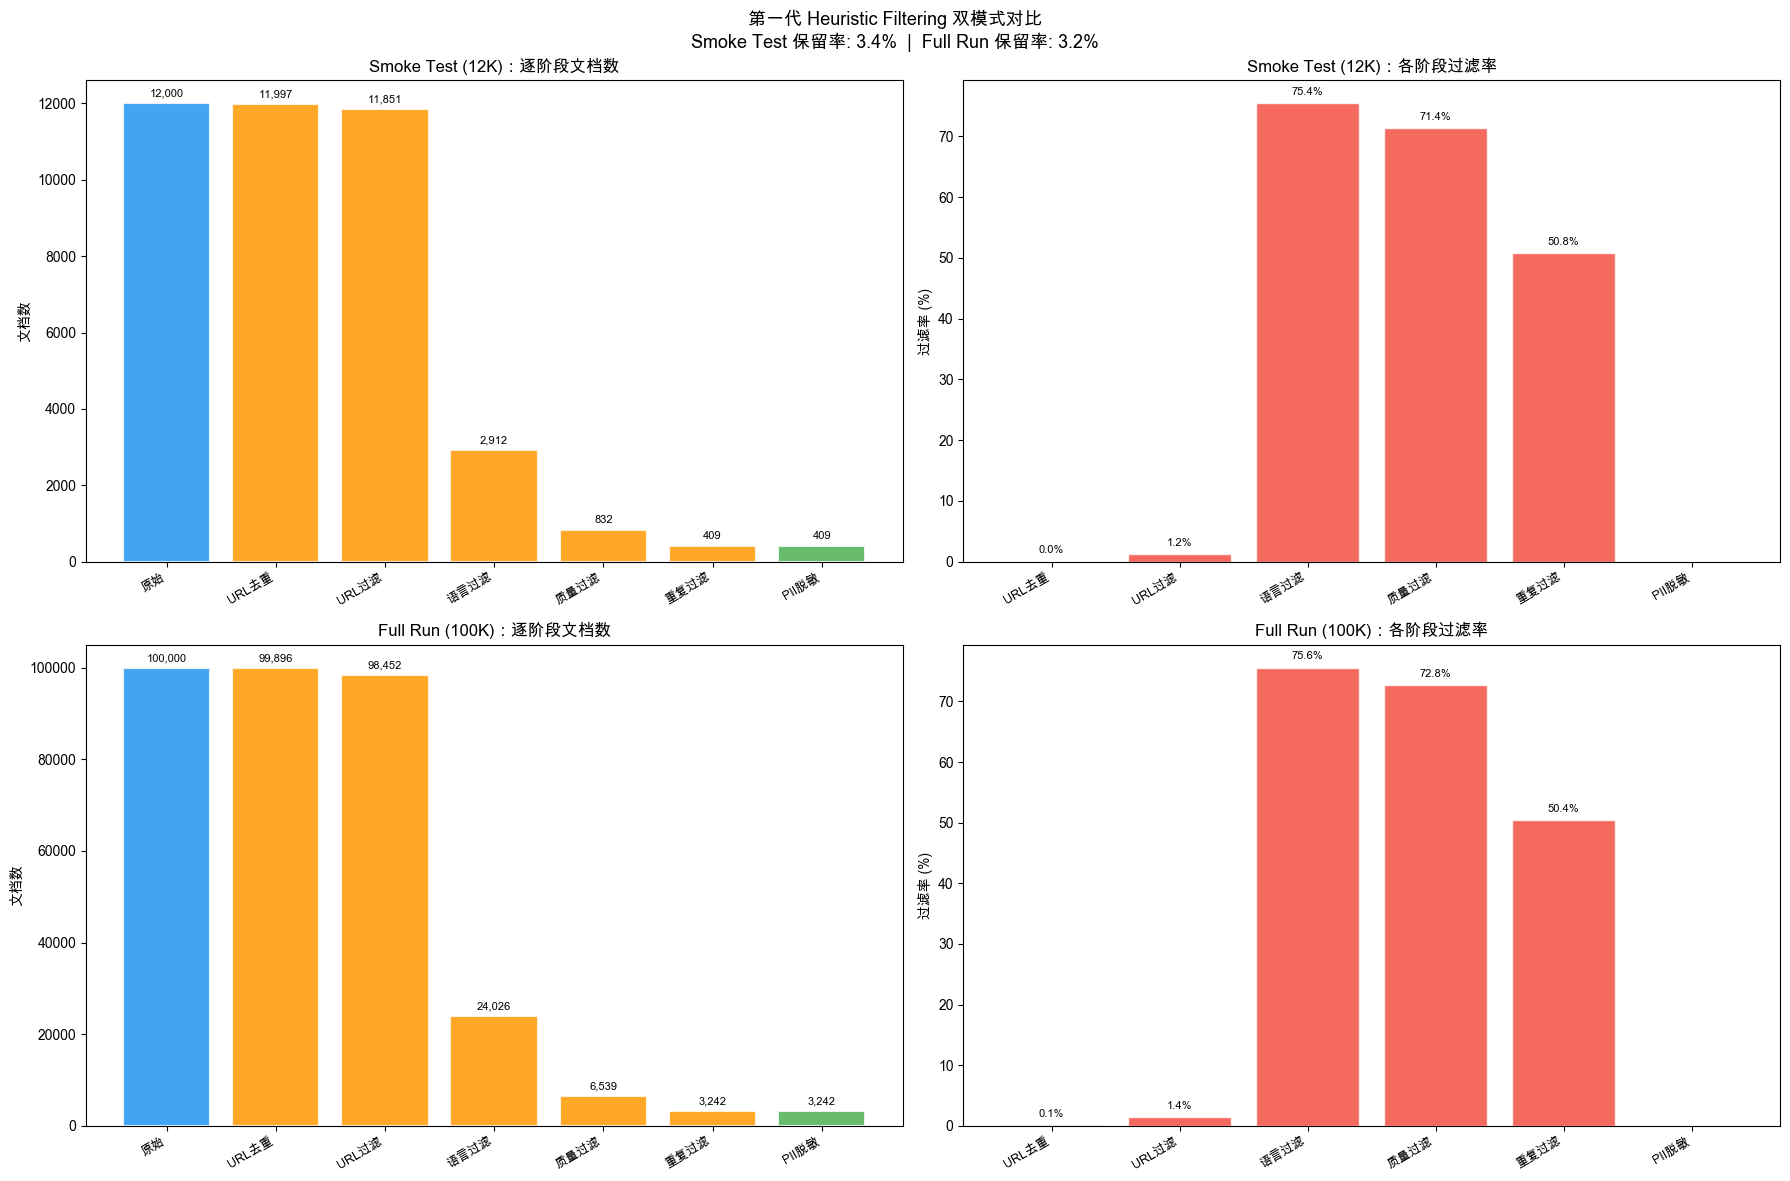

In [4]:
# === Cell D: 双模式瀑布图可视化（2x2 布局） ===
# 上行：smoke_test 的文档数瀑布 + 过滤率
# 下行：full_run 的文档数瀑布 + 过滤率
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# 阶段名称映射
step_names_ordered = {
    'url_dedup': 'URL去重',
    'url_filter': 'URL过滤',
    'language_filter': '语言过滤',
    'quality_filter': '质量过滤',
    'repetition_filter': '重复过滤',
    'pii_filter': 'PII脱敏',
    'toxicity_filter': '毒性过滤',
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for row_idx, mode in enumerate(MODES):
    d = dual_data[mode]
    label = MODE_LABELS[mode]

    # 构建阶段序列
    stages = ['原始']
    counts = [d['input_count']]
    filter_rates = [0.0]

    for s in d['pipeline_stats']:
        stage_label = step_names_ordered.get(s['step'], s['step'])
        stages.append(stage_label)
        counts.append(s['after'])
        filter_rates.append(s['filter_rate'])

    ax1 = axes[row_idx, 0]
    ax2 = axes[row_idx, 1]

    # --- 左图：文档数瀑布 ---
    colors = ['#2196F3' if i == 0
              else '#4CAF50' if i == len(counts) - 1
              else '#FF9800'
              for i in range(len(counts))]
    bars = ax1.bar(stages, counts, color=colors, alpha=0.85,
                   edgecolor='white', linewidth=1.5)
    ax1.set_ylabel('文档数')
    ax1.set_title(f'{label}：逐阶段文档数', fontweight='bold')
    ax1.set_xticklabels(stages, rotation=30, ha='right', fontsize=9)
    for bar, count in zip(bars, counts):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(counts) * 0.01,
                 f'{count:,}', ha='center', va='bottom', fontsize=8)

    # --- 右图：逐阶段过滤率 ---
    bar_colors = ['#f44336'] * len(stages[1:])
    ax2.bar(stages[1:], [r * 100 for r in filter_rates[1:]],
            color=bar_colors, alpha=0.8, edgecolor='white')
    ax2.set_ylabel('过滤率 (%)')
    ax2.set_title(f'{label}：各阶段过滤率', fontweight='bold')
    ax2.set_xticklabels(stages[1:], rotation=30, ha='right', fontsize=9)
    # 在条形上标注数值
    for j, r in enumerate(filter_rates[1:]):
        if r > 0:
            ax2.text(j, r * 100 + 1, f'{r:.1%}', ha='center', va='bottom', fontsize=8)

plt.suptitle(
    f'第一代 Heuristic Filtering 双模式对比\n'
    f'Smoke Test 保留率: {dual_data["smoke_test"]["retention_rate"]:.1%}  |  '
    f'Full Run 保留率: {dual_data["full_run"]["retention_rate"]:.1%}',
    fontweight='bold', fontsize=13
)
plt.tight_layout()

import os
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/02_gen1_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## E. 第一代汇总结论

In [5]:
# === Cell E: 双模式最终汇总统计 ===
# 同时展示 smoke_test 和 full_run 两档的最终结论

print("=" * 70)
print("  第一代 Heuristic Filtering — 双模式最终结论")
print("=" * 70)

for mode in MODES:
    d = dual_data[mode]
    label = MODE_LABELS[mode]

    # 从 stage_metrics 获取 token 统计
    est_tokens = 0
    avg_tokens = 0
    output_metrics = [m for m in d['stage_metrics'] if m.get('stage') == 'gen1_output']
    if output_metrics:
        est_tokens = output_metrics[0].get('estimated_total_tokens', 0)
        avg_tokens = output_metrics[0].get('avg_tokens_per_doc', 0)

    print(f"\n  [{label}]")
    print(f"  {'─' * 50}")
    print(f"  输入文档数:     {d['input_count']:>10,}")
    print(f"  输出文档数:     {d['output_count']:>10,}")
    print(f"  总保留率:       {d['retention_rate']:>10.1%}")
    if est_tokens > 0:
        print(f"  估算 Token 数:  {est_tokens:>10,}")
        print(f"  平均 Token/文档: {avg_tokens:>10,.1f}")

# 双模式过滤贡献对比
print(f"\n{'=' * 70}")
print(f"  各阶段过滤贡献对比（占总过滤量的百分比）")
print(f"{'=' * 70}")
print(f"{'阶段':<32} {'Smoke Test':>12} {'Full Run':>12}")
print(f"{'─' * 70}")

for step in [s['step'] for s in dual_data['smoke_test']['pipeline_stats']]:
    name = step_names.get(step, step)
    parts = []
    for mode in MODES:
        d = dual_data[mode]
        total_filtered = d['input_count'] - d['output_count']
        step_data = next((s for s in d['pipeline_stats'] if s['step'] == step), None)
        if step_data and step_data['filtered'] > 0 and total_filtered > 0:
            pct = step_data['filtered'] / total_filtered
            parts.append(f"{pct:>10.1%}")
        else:
            parts.append(f"{'0.0%':>10}")
    print(f"  {name:<30} {parts[0]:>12} {parts[1]:>12}")

# 一致性结论
smoke_rate = dual_data['smoke_test']['retention_rate']
full_rate = dual_data['full_run']['retention_rate']
diff_pct = abs(smoke_rate - full_rate) / full_rate * 100

print(f"\n{'=' * 70}")
print(f"  一致性分析")
print(f"{'=' * 70}")
print(f"  Smoke Test 保留率: {smoke_rate:.2%}")
print(f"  Full Run 保留率:   {full_rate:.2%}")
print(f"  相对差异:          {diff_pct:.1f}%")
if diff_pct < 20:
    print(f"  结论: 两档结果一致性良好，smoke_test 可代表 full_run 的趋势")
else:
    print(f"  结论: 两档结果存在显著差异，需关注数据规模对过滤行为的影响")

print()
print("  下一步 -> Notebook 03：第二代 Model-based Filtering")
print("  预期：fastText 分类器将进一步提升语义质量，但数据量大幅减少")

  第一代 Heuristic Filtering — 双模式最终结论

  [Smoke Test (12K)]
  ──────────────────────────────────────────────────
  输入文档数:         12,000
  输出文档数:            409
  总保留率:             3.4%
  估算 Token 数:     422,611
  平均 Token/文档:    1,033.3

  [Full Run (100K)]
  ──────────────────────────────────────────────────
  输入文档数:        100,000
  输出文档数:          3,242
  总保留率:             3.2%
  估算 Token 数:   3,757,931
  平均 Token/文档:    1,159.1

  各阶段过滤贡献对比（占总过滤量的百分比）
阶段                                 Smoke Test     Full Run
──────────────────────────────────────────────────────────────────────
  URL 去重                                 0.0%         0.1%
  URL 过滤                                 1.3%         1.5%
  语言过滤                                  77.1%        76.9%
  质量过滤 (Gopher+C4+FineWeb)              17.9%        18.1%
  重复过滤                                   3.6%         3.4%
  PII 脱敏                                 0.0%         0.0%

  一致性分析
  Smoke Test 保留率: 3.41%
  Full Run 保留率:   3.24%
